In [40]:
import glob

import scipy.stats as stats
import scipy.integrate
import numpy as np

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pickle
import rubinml

/Users/duncan/Documents/code/physics/repos/rubin_sim/rubin_sim/utils/__init__.py:6: DeprecationWarning: rubin_sim.utils is deprecated, switch to rubin_scheduler.utils
  warnings.warn("rubin_sim.utils is deprecated, switch to rubin_scheduler.utils", DeprecationWarning)


In [5]:
rates_files = glob.glob('/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/*.pickle')

In [6]:
rates_by_mass = {}
for rate_file in rates_files:
  print(rate_file)
  try:
    with open(rate_file, 'rb') as f:
      rates, info = pickle.load(f)
  except:
    print('failed')
    pass
  rates_by_mass[info['pbhmass']] = rubinml.rates_to_rubin_counts(rates)

/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728633317_ut-5_m-1.00e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728633749_ut-5_m-1.78e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728634173_ut-5_m-3.16e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728634596_ut-5_m-5.62e-12sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728635020_ut-5_m-1.00e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728635441_ut-5_m-1.78e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728635865_ut-5_m-3.16e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728636287_ut-5_m-5.62e-11sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/rates_ml_rates_1728636701_ut-5_m-1.00e-10sm.pickle
/Volumes/thesis/rubin-sim/userdata/opsim_ml/rates/10k/r

In [7]:
ratedf = pd.DataFrame(rates_by_mass.items(), columns=['pbhmass', 'rate'])

In [8]:
rubinml.rates_to_rubin_counts(rates)

1

In [9]:
rate = 137208

In [10]:
def exclusion_from_rate(lambda_0=0,k_obs=0, confidence_level=0.95):
  if lambda_0 == 0:
    return 1
  # Compute the upper limit for the Poisson mean using the inverse CDF
  # ppf gives the value of the parameter such that the CDF is equal to the given percentile
  upper_limit_lambda = stats.poisson.ppf(confidence_level, k_obs + 1)

  # If you have a known baseline rate (lambda_0), calculate the upper limit for the modulation factor (mu)
  upper_limit_mu = upper_limit_lambda / lambda_0

  return min(upper_limit_mu,1)

In [11]:
exclusions = {}
for mass, rate in rates_by_mass.items():
  exclusions[mass] = exclusion_from_rate(rate)

In [12]:
exclusions_min = {}
for mass, rate in rates_by_mass.items():
  exclusions_min[mass] = exclusion_from_rate(rate*0.5+819236, k_obs=819236)

In [13]:
exclusion_df = pd.DataFrame(exclusions.items(), columns=['pbhmass', 'exclusion'])

In [14]:
exclusion_min_df = pd.DataFrame(exclusions_min.items(), columns=['pbhmass', 'exclusion'])

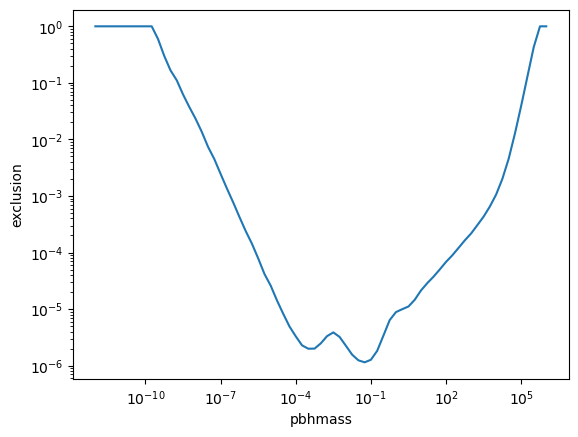

In [15]:
sns.lineplot(exclusion_df, x='pbhmass',y='exclusion')
plt.xscale('log')
plt.yscale('log')

Text(0.5, 1.0, '95% Exclusions on PBH fraction of dark matter for baseline LSST \nwith worst case background from NSC data')

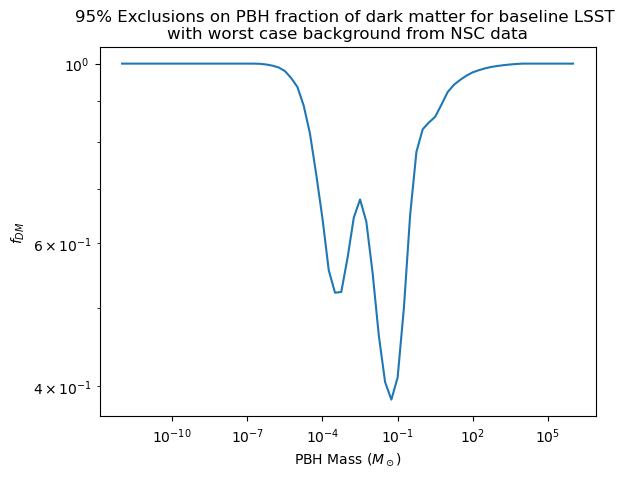

In [17]:
sns.lineplot(exclusion_min_df, x='pbhmass',y='exclusion')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel(r'$f_{DM}$')
plt.title('95% Exclusions on PBH fraction of dark matter for baseline LSST \nwith worst case background from NSC data')
# plt.savefig()

In [18]:
result_files_wide10k = glob.glob('/Volumes/thesis/rubin-sim/userdata/'
                         'opsim_ml/wide10k/detections/*.pickle')
ndetections = []
masses = []
opsims= []
for file in result_files_wide10k:
  with open(file, 'rb') as f:
    events_info, detections = pickle.load(f)
    masses.append(events_info['pbhmass'])
    opsims.append(events_info['opsim'])
    ndetections.append(np.sum(detections)/detections.shape[0])

In [19]:
det_df = pd.DataFrame({'eff':np.array(ndetections),
                       'pbhmass' : masses,
                       'opsim' : opsims})

In [20]:
eff_df = det_df[det_df['opsim']=='baseline_v3.6_10yrs'].sort_values('pbhmass').reset_index(drop=True)

In [21]:
eff_df['pbhmass']

0     1.000000e-12
1     3.162278e-12
2     1.000000e-11
3     3.162278e-11
4     1.000000e-10
5     3.162278e-10
6     1.000000e-09
7     3.162278e-09
8     1.000000e-08
9     3.162278e-08
10    1.000000e-07
11    3.162278e-07
12    1.000000e-06
13    3.162278e-06
14    1.000000e-05
15    3.162278e-05
16    1.000000e-04
17    3.162278e-04
18    1.000000e-03
19    3.162278e-03
20    1.000000e-02
21    3.162278e-02
22    1.000000e-01
23    3.162278e-01
24    1.000000e+00
25    3.162278e+00
26    1.000000e+01
27    3.162278e+01
28    1.000000e+02
29    3.162278e+02
30    1.000000e+03
31    3.162278e+03
32    1.000000e+04
33    3.162278e+04
34    1.000000e+05
35    3.162278e+05
36    1.000000e+06
Name: pbhmass, dtype: float64

In [22]:
rates_by_mass.keys()

dict_keys([1e-12, 1.7782794100389228e-12, 3.1622776601683794e-12, 5.6234132519034904e-12, 1e-11, 1.7782794100389227e-11, 3.1622776601683794e-11, 5.6234132519034906e-11, 1e-10, 1.778279410038923e-10, 3.1622776601683795e-10, 5.623413251903491e-10, 1e-09, 1.7782794100389228e-09, 3.1622776601683795e-09, 5.623413251903491e-09, 1e-08, 1.7782794100389228e-08, 3.162277660168379e-08, 5.6234132519034905e-08, 1e-07, 1.7782794100389227e-07, 3.162277660168379e-07, 5.62341325190349e-07, 1e-06, 1.778279410038923e-06, 3.162277660168379e-06, 5.623413251903491e-06, 1e-05, 1.778279410038923e-05, 3.1622776601683795e-05, 5.623413251903491e-05, 0.0001, 0.00017782794100389227, 0.00031622776601683794, 0.0005623413251903491, 0.001, 0.0017782794100389228, 0.0031622776601683794, 0.005623413251903491, 0.01, 0.01778279410038923, 0.03162277660168379, 0.05623413251903491, 0.1, 0.1778279410038923, 0.31622776601683794, 0.5623413251903491, 1.0, 1.7782794100389228, 3.1622776601683795, 5.623413251903491, 10.0, 17.7827941

In [23]:
det_counts = {}
for mass, rate in rates_by_mass.items():
  if mass not in eff_df['pbhmass'].unique():
    continue
  try:
    eff  = eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'].iloc[0]
  except:
    print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
  # print(mass)
  print(eff)
  det_counts[mass] = rate * eff
det_counts_df = pd.DataFrame(det_counts.items(), columns=['pbhmass', 'Detected events (baseline)'])

0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0101
0.0099
0.0096
0.0089
0.0109
0.012
0.0177
0.0292
0.0462
0.0717
0.1065
0.1278
0.1787
0.2281
0.2752
0.3134
0.3681
0.3969
0.4198
0.4192
0.4025
0.3618
0.3161
0.2762
0.2332
0.2093
0.198
0.1956


In [24]:
exclusions = {}
for mass, rate in rates_by_mass.items():
  if mass not in eff_df['pbhmass'].unique():
    continue
  try:
    eff  = eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'].iloc[0]
  except:
    print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
  # print(mass)
  print(eff)
  exclusions[mass] = exclusion_from_rate(rate * eff)

0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0101
0.0099
0.0096
0.0089
0.0109
0.012
0.0177
0.0292
0.0462
0.0717
0.1065
0.1278
0.1787
0.2281
0.2752
0.3134
0.3681
0.3969
0.4198
0.4192
0.4025
0.3618
0.3161
0.2762
0.2332
0.2093
0.198
0.1956


In [25]:
exclusions_min = {}
for mass, rate in rates_by_mass.items():
  if mass not in eff_df['pbhmass'].unique():
    continue
  try:
    eff  = eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'].iloc[0]
  except:
    print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
  # print(mass)
  print(eff)
  exclusions_min[mass] = exclusion_from_rate(rate * eff * .5 + 819236, 819236)

0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0082
0.0101
0.0099
0.0096
0.0089
0.0109
0.012
0.0177
0.0292
0.0462
0.0717
0.1065
0.1278
0.1787
0.2281
0.2752
0.3134
0.3681
0.3969
0.4198
0.4192
0.4025
0.3618
0.3161
0.2762
0.2332
0.2093
0.198
0.1956


In [26]:
exclusion_df = pd.DataFrame(exclusions.items(), columns=['pbhmass', 'exclusion'])

In [27]:
exclusion_min_df = pd.DataFrame(exclusions_min.items(), columns=['pbhmass', 'exclusion'])

Text(0.5, 1.0, '95% Exclusions on PBH fraction of dark matter for baseline LSST')

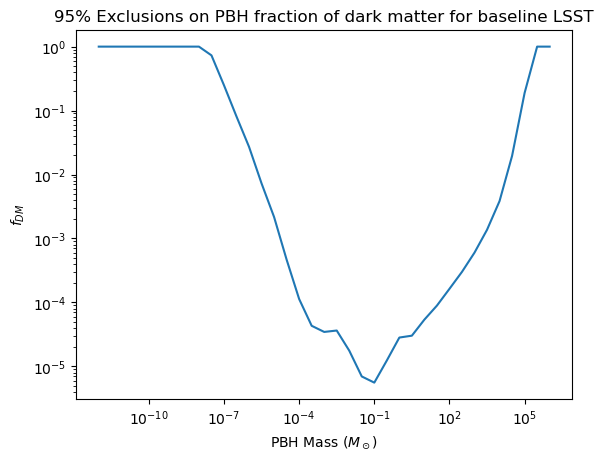

In [28]:
sns.lineplot(exclusion_df, x='pbhmass',y='exclusion')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel(r'$f_{DM}$')
plt.title('95% Exclusions on PBH fraction of dark matter for baseline LSST')

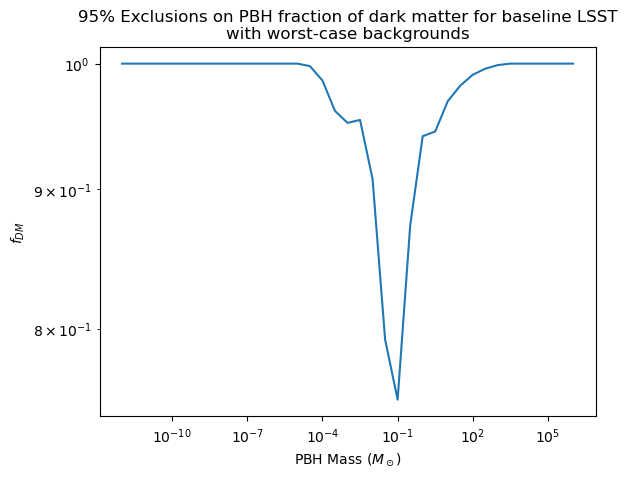

In [29]:
sns.lineplot(exclusion_min_df, x='pbhmass',y='exclusion')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel(r'$f_{DM}$')
plt.title('95% Exclusions on PBH fraction of dark matter for baseline LSST\n'
          'with worst-case backgrounds')
plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/rubinsim/exclusions-worst-case-temp.pdf')

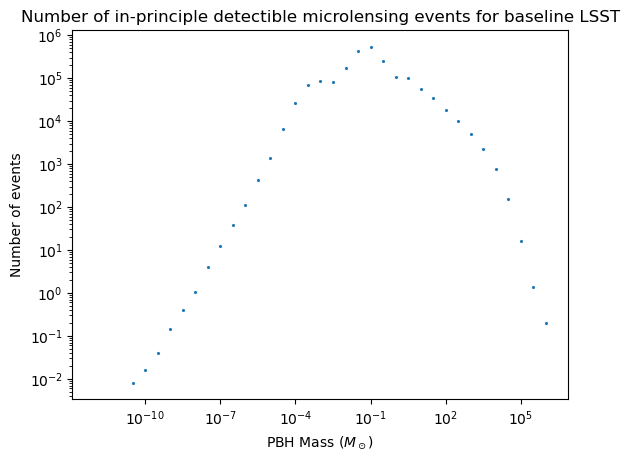

In [30]:
sns.lineplot(det_counts_df, x='pbhmass',y='Detected events (baseline)',linestyle='None',marker='.')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel(r'Number of events')
plt.title('Number of in-principle detectible microlensing events for baseline LSST')
plt.savefig('/Users/duncan/Documents/code/physics/dissertation/ims/rubinsim/n-events-by-pbhmass.pdf')

In [39]:

def bhmf(m: float, mc=6.3, ms=1.6):
  """Milky way black hole mass density function, as an exponential with cutofff
      defaults to fig 2 of https://arxiv.org/pdf/1006.2834
  Args:
      m (float): Mass in question (SM)
      mc (float): Cutoff mass (SM)
      ms (float): Mass scale (SM)
  """

  return (np.exp((mc-m)/ms)/ms)*(m>mc)

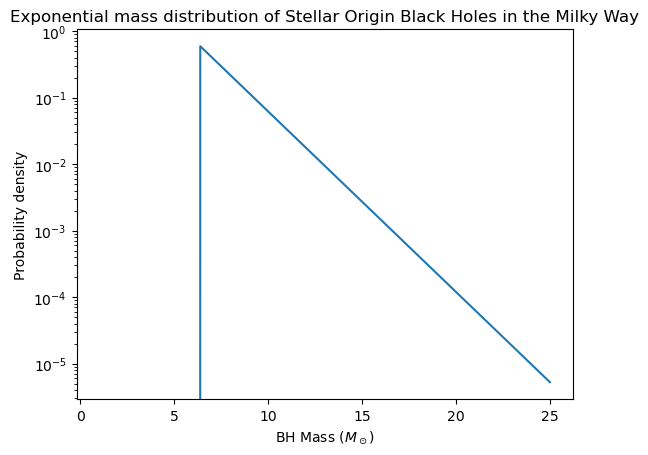

In [68]:
xs = np.linspace(1,25,50)
# ys = np.logspace(-2,0)
ys = bhmf(xs)
plt.plot(xs,ys)
plt.xlabel(r'BH Mass ($M_\odot$)')
plt.ylabel('Probability density')
plt.title('Exponential mass distribution of Stellar Origin Black Holes in the Milky Way')
plt.yscale('log')


In [42]:
scipy.integrate.quad(bhmf,6.3,100)

(0.9999999999999994, 2.1789394282476816e-10)

In [50]:
def get_sobh_counts(m, width=2.):
  return scipy.integrate.quad(bhmf,m/width,m*width)
def get_bucketed_bhs(masses, width=2.):
  """Evaluate number of background indistinguishable SOBHs 
     at some masses, by integrating the mass density function
     around a factor of width to either side of each mass

  Args:
      masses (iterable): List of masses (SM)
      width (float, optional): Factor away from each mass to integrate. Defaults to 2.
  """
  counts = {}
  for m in masses:
    counts[m] = scipy.integrate.quad(bhmf,m/width,m*width)
  return counts

    

In [66]:
n_bh = 100*10**6
tot_dm = 1.37*10**11 # total DM mass in MW, according to https://doi.org/10.1051/0004-6361/201833355
exclusions_sobh = {}
for mass, rate in rates_by_mass.items():
  n_bh_mass = ( n_bh / (tot_dm / mass ) ) * get_sobh_counts(mass)[0]
  # print(n_bh_mass)
  if mass not in eff_df['pbhmass'].unique():
    continue
  try:
    eff  = eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'].iloc[0]
  except:
    pass
    # print(eff_df[np.isclose(eff_df['pbhmass'],mass)]['eff'])
  # print(mass)
  # print(eff)
  exclusions_sobh[mass] = exclusion_from_rate(rate * eff * (1 + n_bh_mass), rate * eff * n_bh_mass)

In [63]:
exclusion_sobh_df = pd.DataFrame(exclusions_sobh.items(), columns=['pbhmass', 'exclusion'])

Text(0.5, 1.0, '95% Exclusions on PBH fraction of dark matter for baseline LSST\nwith stellar origin BH backgrounds')

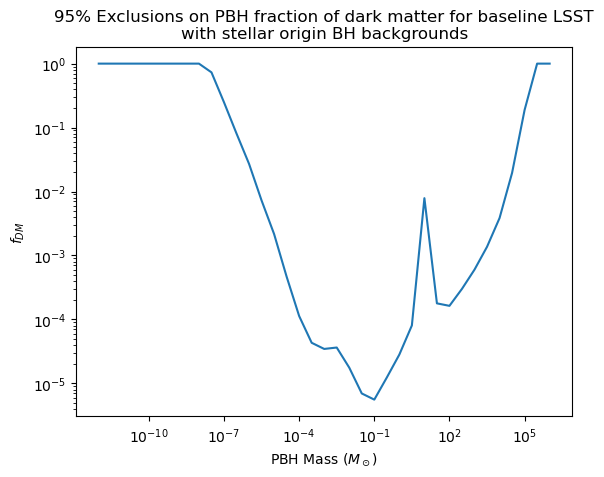

In [65]:
sns.lineplot(exclusion_sobh_df, x='pbhmass',y='exclusion')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'PBH Mass ($M_\odot$)')
plt.ylabel(r'$f_{DM}$')
plt.title('95% Exclusions on PBH fraction of dark matter for baseline LSST\n'
          'with stellar origin BH backgrounds')